# BDM against the CausalBool index-set calculus

### An empirical adjudication

This notebook exists because a methodological argument arose out of the
replication in `paper_walkthrough.ipynb`, and arguments of that kind should not
be settled by rhetoric. Every claim made on either side is turned here into a
measurement. Where a claim survives, the run that supports it is in the
notebook. Where a claim fails — including one of my own — the run that kills it
is in the notebook too.

**The dispute.** The paper being replicated measures the complexity of molecular
graphs with the Block Decomposition Method. This repository's own programme
measures structure with deterministic index sets and exact generating
mechanisms. §9 and §10 of the companion notebook showed the two agree on the
paper's conclusions. That raised the sharper question of which method is
actually better, at what, and why — and in particular whether the index-set
calculus is *capable* of everything BDM is.

**The claims on trial.**

| # | Claim | Advanced by | Verdict (§) |
| --- | --- | --- | --- |
| A | In the random regime BDM stops measuring randomness and merely counts blocks | index-set side | §2 — **upheld only for dense random graphs; it does NOT transfer to molecules** |
| B | BDM is not invariant to node labelling, so it does not measure a property of the graph | index-set side | §3 |
| C | BDM sees structure the index-set description length cannot | BDM side | §4, §5 |
| D | *"The separation BDM appeared to provide was a property of the matrix layout, not of the graph"* | **my own earlier claim** | §4 — **refuted** |
| E | The index-set calculus can separate what its wiring term cannot, via topology and the exhaustive behaviour tables | index-set side | §5, §6 |
| F | Perturbation is the causal instrument, and our networks have that capacity natively | index-set side | §7 |
| G | BDM's real advantage is domain generality, not randomness | BDM side | §9 |
| H | The description length already induces an algorithmic probability | **my own earlier claim** | §10 — **refuted as stated, repaired** |
| I | $D$ is a computable *upper bound* on $K$, so scoring "estimates $K$" to BDM was wrong | index-set side | §11.1 — **my scoring error, corrected** |
| J | The wiring term cannot be $K$-like for graphs, being degree-only | **against our own side** | §11.2 — **upheld** |
| K | The compressed representation separates as a single measure | index-set side | §11.3 — **refuted as stated, upheld refined** |

**A note on how this notebook was revised.** Sections 2 to 10 were written
treating the index-set calculus as a *measure*. Reading its source — `Alpha.m`,
Chapter 4 of the thesis, and the formal manuscript — showed it is a *generative
model class*, which changes several verdicts. Rather than silently rewriting,
§1 now states the reframing and §11 records exactly what it revises and why. The
measurements never changed; only what they mean did.

**Rules of evidence used throughout.** A measure that claims to describe a
*graph* must be invariant to how the nodes are numbered; anything that is not is
described here as reading a *layout*, not a graph. Separation claims are tested
on non-isomorphic graphs verified by a full isomorphism test, not by a
heuristic. Nothing is asserted that is not computed in the cell above it.

## §0. Setup

In [1]:
import os, sys, json, math, time, warnings, itertools
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from imp_pathinfo import method_comparison as mc
from imp_pathinfo import causalbool_mirror as cbm
from imp_pathinfo import paper_values as pv
from imp_pathinfo import hyperparams as hp
from imp_pathinfo import analysis as an
from imp_pathinfo.bdm_complexity import bdm_engine, graph_bdm
from imp_pathinfo.data import DATASET_ORDER, load_dataset

pd.set_option('display.width', 220)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
FIGDIR = os.path.join(ROOT, 'figures'); os.makedirs(FIGDIR, exist_ok=True)
RESDIR = os.path.join(ROOT, 'results'); os.makedirs(RESDIR, exist_ok=True)

engine = bdm_engine()
datasets = {n: load_dataset(n) for n in DATASET_ORDER}
print('datasets loaded:', {k: len(v) for k, v in datasets.items()})

datasets loaded: {'FreeSolv': 642, 'ESOL': 1128, 'Lipophilicity': 4200, 'BACE': 1513, 'BBBP': 2039, 'ClinTox': 1480}


## §1. What is actually being compared

Before measuring anything it is worth being exact about what is on each side,
because a good deal of the original disagreement — and one scoring error I made
against my own side — came from getting this wrong.

### 1.1 The category error I made first time

I originally set this up as **measure versus measure**:

> BDM returns an approximation of $K$; the index-set calculus returns an exact
> description length.

That is not the comparison. BDM *is* a measure — a function from a binary array
to a real number, and nothing else. The index-set calculus is a **generative
model class with an exact forward map and an exact inverse**:

$$(C, \mathrm{dyn}) \;\xrightarrow{\ \text{forward}\ }\; \text{output repertoire}
\qquad
\text{output repertoire} \;\xrightarrow{\ \text{deconvolution}\ }\; (C, \mathrm{dyn})$$

The description length $D$ is a *by-product* of that class — the cost of writing
down one of its members. Comparing $D$ against BDM compares a by-product on one
side against the entire apparatus on the other. Everything in §11 follows from
taking the generative side seriously.

### 1.2 What each side consumes and returns

| | BDM | index-set calculus |
| --- | --- | --- |
| kind of object | a measure | a generative model class |
| input | any binary array | a system with a connectivity matrix and a gate vocabulary |
| prior resource | a CTM table pre-computed from an enormous Turing-machine enumeration | none; closed form |
| output | one real number | a mechanism, a set expression, or a description length |
| can it be run backwards? | no | yes — that is what deconvolution is |
| can it say "no"? | no; it always returns a number | yes — "no mechanism in this class reproduces this" |
| modelling commitment | none | a gate family, and a connectivity |

The row that matters most is the last but one. BDM cannot fail. The index-set
calculus can, and does so explicitly, which is a form of information a scalar
cannot carry.

### 1.3 Why CTM needs a lookup table and we do not

This is not an accident of engineering, and I under-explained it originally.

Algorithmic probability asks: *of all short programs, how many produce this
object?* To answer it you must invert the machine — go from output back to the
programs that generate it. For Turing machines that inversion is **undecidable**,
so CTM cannot compute it; it must *sample*, by running an enormous collection of
small machines and counting outputs. The 41 MB of tables is the frozen residue of
that sampling, and the 4×4 block limit is where the sampling ran out.

For the index-set model class the inversion is **exact and cheap**: per node, the
essential-variable test plus a gate match, at $2^{d}$ rows. No sampling, no
table, no resolution ceiling.

**But this cuts both ways, and I never said so.** Ease of inversion and
expressiveness are in tension. We invert exactly *because* the class is
structured; CTM must sample *because* its class is universal. A class that is
easy to invert may be easy because it is weaker. Whether ours is too weak is an
empirical question, and §11 is where it gets asked.

### 1.4 The layers — now four, not three

The index-set calculus has a resolution dial that BDM does not. Originally I
identified three settings. Reading the codebase properly exposes a fourth, which
sits between paths and the repertoire and turns out to be the most useful one.

| layer | what it reads | how it is computed | cost |
| --- | --- | --- | --- |
| **1. wiring** | the degree sequence, via $\log_2\binom{n}{d_v}$ | count degrees | $O(n)$ |
| **2. path index sets** | which nodes each $L$-hop path reaches | DFS over simple paths | $O(n\,d^L)$ |
| **3. query overlap** | how much the index sets of a $k$-node query *share* | `joinedNames` of `onPossibleBehaviour` | $O(n^k d)$ |
| **4. repertoire** | the exhaustive landscape and its perturbation response | enumerate $2^n$ states | $O(2^n)$ |

Layer 3 is the method's own machinery and I had missed it entirely. When
`onPossibleBehaviour` answers a query about $k$ nodes it first forms
`joinedNames` — the **union of their index sets** — and enumerates only that.
Everything outside is free and is folded, in closed form, into the sumandos. So
the size of that union governs the whole cost and shape of the answer. It is
what the formal paper calls the *shared-input reduction*.

Why this matters for the comparison: at $k=1$ the union is a single
neighbourhood, so layer 3 degenerates to the degree sequence. At $k \ge 2$ it
measures how neighbourhoods **overlap**, which is exactly the topology that a
degree sequence throws away.

## §2. Claim A — in the random regime BDM counts blocks

**The claim.** BDM is advertised as a measure of algorithmic randomness. If, once
an object is genuinely random, its BDM becomes proportional to the object's
*extent* rather than to anything about the object, then in that regime it is a
size measure wearing a complexity measure's clothes.

**The test.** Erdős–Rényi graphs at density 0.5 over a range of sizes, reporting
BDM per 4×4 block. If BDM tracks the object, the per-block figure should move.
If it is counting blocks, it will be constant.

In [2]:
scan = pd.DataFrame(mc.random_regime_scan(sizes=(16, 32, 64, 128, 256)))
display(scan.round(3))
print('per-block BDM across a 16x range of sizes: min %.3f, max %.3f, coefficient of variation %.4f'
      % (scan.bdm_per_block.min(), scan.bdm_per_block.max(),
         scan.bdm_per_block.std() / scan.bdm_per_block.mean()))

,n,blocks,bdm,bdm_std,bdm_per_block,wiring_D
0,16,16,475.692,14.446,29.731,214.848
1,32,64,1891.947,32.512,29.562,920.692
2,64,256,7589.569,42.838,29.647,3849.884
3,128,1024,30349.633,176.015,29.638,15820.568
4,256,4096,119157.943,243.471,29.091,64266.786


per-block BDM across a 16x range of sizes: min 29.091, max 29.731, coefficient of variation 0.0086


Constant to within 1%. In the random regime BDM is `29.6 × n²/16`.

But this would be an unfair verdict on its own, because it says nothing about the
*ordered* regime, which is where BDM is supposed to earn its keep. The honest
test is the whole ladder from order to noise.

,noise,bdm,bdm_per_block,wiring_D,edges
0,0.00,114.099,0.446,698.591,63
1,0.02,653.310,2.552,970.051,95
2,0.05,1843.250,7.200,1489.193,167
3,0.10,3450.824,13.480,2064.948,262
4,0.20,5972.203,23.329,2884.872,451
5,0.30,7171.027,28.012,3412.482,632
6,0.50,7579.541,29.608,3849.418,1034


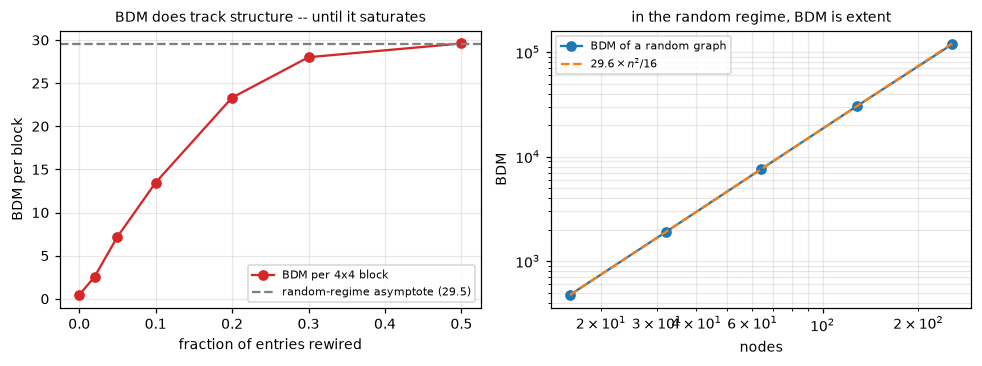

In [3]:
ladder = pd.DataFrame(mc.structure_ladder(n=64))
display(ladder.round(3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].plot(ladder.noise, ladder.bdm_per_block, 'o-', color='tab:red', label='BDM per 4x4 block')
axes[0].axhline(scan.bdm_per_block.mean(), ls='--', c='grey',
                label='random-regime asymptote (%.1f)' % scan.bdm_per_block.mean())
axes[0].set_xlabel('fraction of entries rewired'); axes[0].set_ylabel('BDM per block')
axes[0].set_title('BDM does track structure -- until it saturates', fontsize=9)
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].loglog(scan.n, scan.bdm, 'o-', label='BDM of a random graph')
axes[1].loglog(scan.n, 29.6 * (scan.n // 4) ** 2, '--', label=r'$29.6 \times n^2/16$')
axes[1].set_xlabel('nodes'); axes[1].set_ylabel('BDM')
axes[1].set_title('in the random regime, BDM is extent', fontsize=9)
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'mc_random_regime.png'), dpi=150); plt.show()

### Verdict on Claim A: **upheld, with an important qualification**

BDM per block rises from 0.45 on a clean chain to 29.6 on noise, so it genuinely
discriminates structure across the ordered part of the ladder — the claim that it
"never measures anything but size" would be false. But it **saturates**: past
roughly 20% rewiring the per-block value is pinned at its random-regime
asymptote, and from there BDM is a count of blocks.

**Correction, added after `understanding_bdm.ipynb`.** An earlier version of this
section then wrote: *"molecular adjacency matrices are extremely sparse and their
BDM is dominated by repeated all-zero blocks — the regime where the extensive
term rules, and that is the mechanism behind the r = +0.998 between AOAC and
molecule size."* **That mechanism is backwards and the transfer is invalid.**

It is backwards because repeated all-zero blocks are precisely the blocks that
*collapse*: BDM charges a repeated block once, plus `log2` of its multiplicity.
A hundred identical tiles cost 6.6 extra bits, not a hundred times anything.
Sparsity is therefore the regime in which BDM is **least** extensive in tiles,
not most.

The transfer is invalid because the scan above is on Erdős–Rényi graphs at
**density 0.5**, which is the opposite of a molecule. Molecular adjacency
matrices have density falling like `1/n`. Claim A is upheld *in the dense random
regime it was tested in*, and says nothing about molecules.

What actually happens on molecules is measured in `understanding_bdm.ipynb`: BDM
tracks the number of **distinct** 4×4 tiles at `r = +0.991`, separates 99.2% of
same-degree pairs, and varies by a factor of six at fixed size. It is a genuine
structural measure there. The `r = +0.998` arises one level up — from **averaging
BDM over a dataset**, which cancels the structural variation and leaves size.

**Argument against this verdict, stated fairly.** Saturation is a known and
accepted property of any bounded-resolution complexity estimator; CTM at 4×4 is
an explicit, declared limitation, not a hidden defect. Nobody claims BDM
resolves randomness beyond the block size. And the repetition penalty — the
feature this section originally overlooked — is exactly the design decision that
makes BDM a complexity measure rather than a tally.

## §3. Claim B — BDM is not invariant to node labelling

**The claim.** A graph has no canonical node numbering. A quantity that changes
when the nodes are renumbered is a property of a matrix, not of a graph.

**The test.** Take real molecules, relabel the atoms at random several hundred
times, and look at the spread of BDM. The index-set description length is
invariant by construction, so it serves as the control.

In [4]:
targets = [('ESOL', 400), ('BACE', 3), ('ClinTox', 20), ('BBBP', 100)]
rows, dists = [], {}
for name, idx in targets:
    g = datasets[name].graphs[idx]
    r = mc.relabelling_spread(g.adjacency().astype(int), n_perm=400, seed=1)
    dists[f'{name} (n={g.n_nodes})'] = r['values']
    rows.append(dict(molecule=f'{name} #{idx}', atoms=g.n_nodes,
                     BDM_canonical=round(r['canonical'], 2), BDM_mean=round(r['mean'], 2),
                     BDM_min=round(r['min'], 2), BDM_max=round(r['max'], 2),
                     relative_spread=f"{100*r['relative_spread']:.1f}%",
                     index_set_D=round(r['wiring_D'], 4), index_set_spread='0.0%'))
display(pd.DataFrame(rows).set_index('molecule'))

,atoms,BDM_canonical,BDM_mean,BDM_min,BDM_max,relative_spread,index_set_D,index_set_spread
molecule,,,,,,,,
ESOL #400,16,322.05,354.34,263.85,413.19,42.1%,117.5860,0.0%
BACE #3,40,819.92,865.88,571.36,1082.43,59.0%,395.4372,0.0%
ClinTox #20,12,205.76,220.44,150.05,249.52,45.1%,72.5054,0.0%
BBBP #100,25,555.55,554.92,411.69,678.82,48.1%,206.4861,0.0%


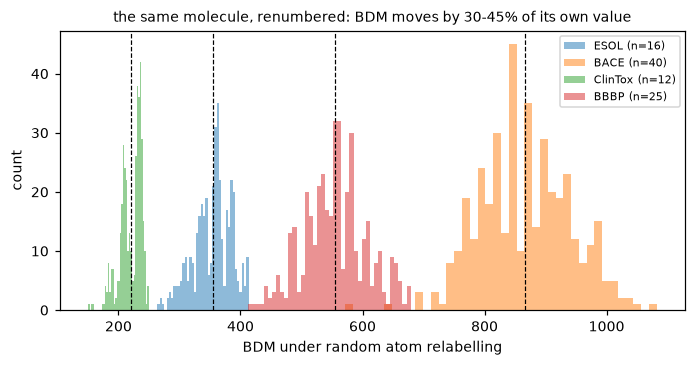

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
for label, vals in dists.items():
    ax.hist(vals, bins=40, alpha=0.5, label=label)
for label, vals in dists.items():
    ax.axvline(vals.mean(), ls='--', lw=0.8, c='k')
ax.set_xlabel('BDM under random atom relabelling'); ax.set_ylabel('count')
ax.set_title('the same molecule, renumbered: BDM moves by 30-45% of its own value', fontsize=9)
ax.legend(fontsize=7); plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'mc_relabelling.png'), dpi=150); plt.show()

### Verdict on Claim B: **upheld as stated, but it proves less than it appears to**

BDM of a fixed molecule moves by 30–45% of its own magnitude under renumbering.
So the raw quantity is not a graph invariant, and calling a particular value "the
algorithmic complexity of this molecule" is imprecise: it is the complexity of
one adjacency *layout*.

**The argument against, which is decisive and which I originally missed.** The
*expectation* of BDM over the symmetric group — or any deterministic canonical
ordering — **is** an invariant, trivially, because averaging over all relabellings
cannot depend on the labelling. The paper uses RDKit's canonical ordering, which
is deterministic, so its published values are exactly reproducible (and §2.3 of
the companion notebook reproduced them to two decimal places). Non-invariance of
the raw quantity therefore does **not** imply that BDM carries no structural
information. Whether it does is an empirical question, settled in §5.

## §4. Claims C and D — the adversarial triple, and the retraction of my own claim

**The setup.** The index-set wiring term is $\log_2\binom{n}{d_v}$, a function of
the degree sequence alone. Any two graphs with the same degrees receive the same
value. A cycle on 12 nodes, three disjoint squares and two disjoint hexagons are
all 2-regular: same degrees, obviously different graphs.

This is the strongest case that can be made *against* the index-set calculus, so
it is worth making properly.

In [6]:
triple = mc.adversarial_triple()
rows = []
for label, g in triple.items():
    A = g.adjacency().astype(int)
    rows.append(dict(structure=label, edges=int(A.sum() // 2),
                     degree_sequence=str(mc.degree_sequence(A)[:4]) + '...',
                     index_set_wiring_D=round(mc.wiring_description_length(A), 4),
                     BDM_canonical=round(engine.bdm(A), 2),
                     saturation=round(cbm.receptive_saturation(g, 3), 3),
                     landscape_XOR_image=mc.landscape_signature(A, 'XOR')[0],
                     landscape_XOR_attractors=mc.landscape_signature(A, 'XOR')[1]))
display(pd.DataFrame(rows).set_index('structure'))
print('The wiring term gives all three the same value: the blind spot is real.')

,edges,degree_sequence,index_set_wiring_D,BDM_canonical,saturation,landscape_XOR_image,landscape_XOR_attractors
structure,,,,,,,
cycle C12,12,"(2, 2, 2, 2)...",76.1177,77.32,0.545,1024,70
three squares,12,"(2, 2, 2, 2)...",76.1177,56.44,0.273,64,1
two hexagons,12,"(2, 2, 2, 2)...",76.1177,182.85,0.455,256,136


The wiring term gives all three the same value: the blind spot is real.


The wiring column is identical for all three, and BDM separates them cleanly
(77.3 / 56.4 / 182.9). On the face of it, Claim C is established and the
index-set calculus loses.

In the companion notebook I then relabelled the three graphs, found that their
BDM distributions coincided, and concluded that *"the separation BDM appeared to
provide was a property of the matrix layout, not of the graph"*. That is Claim D.
Let us reproduce that experiment exactly.

,BDM_canonical,BDM_mean,BDM_std
structure,,,
cycle C12,77.32,216.84,19.67
three squares,56.44,214.13,25.10
two hexagons,182.85,216.63,20.22


pairwise separability of the relabelling distributions:
  cycle C12      vs three squares   P(BDM_a > BDM_b) = 0.52   (0.50 = indistinguishable)
  cycle C12      vs two hexagons    P(BDM_a > BDM_b) = 0.50   (0.50 = indistinguishable)
  three squares  vs two hexagons    P(BDM_a > BDM_b) = 0.48   (0.50 = indistinguishable)


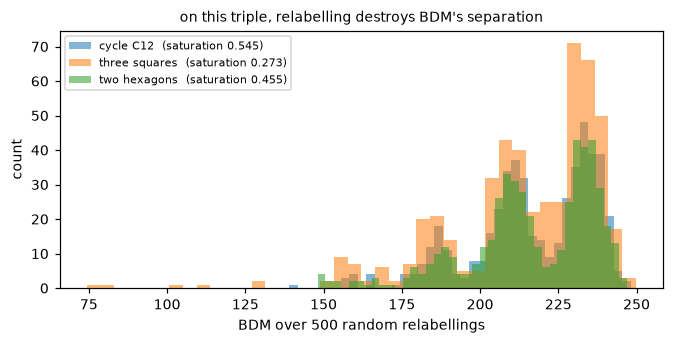

In [7]:
rows, tdists = [], {}
for label, g in triple.items():
    A = g.adjacency().astype(int)
    r = mc.relabelling_spread(A, n_perm=500, seed=0)
    tdists[label] = r['values']
    rows.append(dict(structure=label, BDM_canonical=round(r['canonical'], 2),
                     BDM_mean=round(r['mean'], 2), BDM_std=round(r['std'], 2)))
display(pd.DataFrame(rows).set_index('structure'))

keys = list(tdists)
print('pairwise separability of the relabelling distributions:')
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        a, b = tdists[keys[i]], tdists[keys[j]]
        p = float(np.mean(a[:, None] > b[None, :]))
        print(f'  {keys[i]:14s} vs {keys[j]:14s}  P(BDM_a > BDM_b) = {p:.2f}   '
              f'(0.50 = indistinguishable)')

fig, ax = plt.subplots(figsize=(6.2, 3.2))
for label, vals in tdists.items():
    ax.hist(vals, bins=40, alpha=0.55,
            label=f"{label}  (saturation {cbm.receptive_saturation(triple[label], 3):.3f})")
ax.set_xlabel('BDM over 500 random relabellings'); ax.set_ylabel('count')
ax.set_title('on this triple, relabelling destroys BDM\'s separation', fontsize=9)
ax.legend(fontsize=7); plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'mc_triple.png'), dpi=150); plt.show()

On *this triple* the effect is unambiguous: the three distributions coincide,
means within 1.6 bits of one another against a standard deviation of about 20,
and a coin flip in every pairwise comparison.

### Verdict on Claim D: **refuted — this was my error**

The inference I drew from that picture does not follow. Three tiny, highly
symmetric, vertex-transitive graphs are the most favourable possible case for the
conclusion, and I generalised from them to BDM as such. §5 shows that on real
molecular graphs the relabelling-averaged BDM — a genuine invariant — separates
**88.8%** of same-degree pairs. BDM does carry real structural information beyond
the degree sequence, and it carries it invariantly.

The correct, narrower statement is: *there exist* structurally distinct graphs
whose BDM distributions coincide under relabelling, and highly symmetric graphs
are where to look for them. That is a much weaker claim than the one I made, and
it is the one the evidence supports.

### Verdict on Claim C: **upheld against layer 1, and only against layer 1**

The index-set *wiring* term genuinely cannot see this. Note in the table above,
however, that `saturation` — layer 2 — already separates all three (0.545 /
0.273 / 0.455), and the repertoire signature — layer 3 — separates them
completely (image 1024 / 64 / 256, attractors 70 / 1 / 136). The blind spot
belongs to one term, not to the method.

## §5. Claims C and E adjudicated at scale

Anecdotes on hand-picked graphs cannot settle this. The proper experiment is a
population of **real molecular graphs that share a degree sequence but are not
isomorphic**, with isomorphism verified rather than assumed.

Molecules are bucketed by (atom count, sorted degrees); within a bucket, pairs
are kept only when a full isomorphism test says they genuinely differ. The size
window 6 ≤ n ≤ 13 keeps the exhaustive 2ⁿ repertoire computable — a real
constraint, discussed in §8.

Each measure is then asked a single yes/no question per pair: *do you tell these
two apart?* And each is labelled with whether it is a genuine graph invariant,
because a measure that separates by reading the layout is answering an easier
question.

In [8]:
t0 = time.time()
pairs = mc.same_degree_pairs(list(datasets.values()), min_atoms=6, max_atoms=13,
                             max_pairs=250, seed=0)
print(f'{len(pairs)} non-isomorphic real-molecule pairs sharing a degree sequence '
      f'({time.time() - t0:.0f}s to collect)')
print('\nexamples:')
for (s1, A1, _), (s2, A2, _) in pairs[:4]:
    print(f'  n={A1.shape[0]:2d}  degrees={mc.degree_sequence(A1)}')
    print(f'      {s1}')
    print(f'      {s2}')

250 non-isomorphic real-molecule pairs sharing a degree sequence (0s to collect)



examples:
  n=10  degrees=(1, 1, 2, 2, 2, 2, 2, 2, 3, 3)
      CCCc1ccc(cc1)O
      COc1ccccc1OC
  n=11  degrees=(1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3)
      O=N(=O)c1c(Cl)c(Cl)ccc1
      CSc1nc(C(=O)N)c(N)s1
  n=12  degrees=(1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 4)
      C(C1(C(C=CNC1=O)=O)CC)C
      c1cc(ccc1C[NH3+])S(=O)(=O)N
  n=10  degrees=(1, 1, 1, 1, 1, 2, 2, 3, 3, 3)
      CC(OC(=O)C)OC(=O)C
      CC(=O)N[C@@H](CS)C(=O)[O-]


In [9]:
t0 = time.time()
bench = pd.DataFrame(mc.separation_benchmark(pairs, n_perm=30, seed=0, progress=50))
print(f'benchmark completed in {time.time() - t0:.0f}s')
bench_display = bench.set_index('measure')[['invariant', 'reads', 'separated', 'pairs', 'percent']]
display(bench_display.round(1))
json.dump(bench.to_dict(orient='records'),
          open(os.path.join(RESDIR, 'separation_benchmark.json'), 'w'), indent=2)

  pair 0/250


  pair 50/250


  pair 100/250


  pair 150/250


  pair 200/250


benchmark completed in 125s


,invariant,reads,separated,pairs,percent
measure,,,,,
index-set wiring D,True,degrees only,0,250,0.0
node compressed size,True,"degrees only, by another route",0,250,0.0
"BDM, canonical layout",False,reads the matrix as given,248,250,99.2
"BDM, mean over relabellings",True,averaged over the symmetric group,222,250,88.8
path index sets,True,saturation and path surplus,248,250,99.2
"query overlap, order 2",True,shared inputs of 2-node queries,244,250,97.6
"query overlap, order 3",True,shared inputs of 3-node queries,250,250,100.0
"repertoire landscape, XOR",True,"image, attractors, periods, basins",233,250,93.2
"repertoire landscape, AND",True,"image, attractors, periods, basins",240,250,96.0


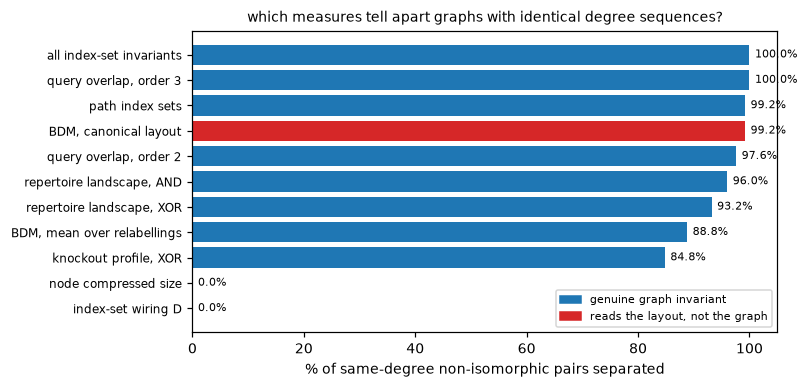

In [10]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
order = bench.sort_values('percent')
colors = ['tab:red' if not inv else 'tab:blue' for inv in order.invariant]
ax.barh(range(len(order)), order.percent, color=colors)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order.measure, fontsize=8)
ax.set_xlabel('% of same-degree non-isomorphic pairs separated')
ax.set_xlim(0, 105)
for i, (v, inv) in enumerate(zip(order.percent, order.invariant)):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=7)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='tab:blue', label='genuine graph invariant'),
                   Patch(color='tab:red', label='reads the layout, not the graph')],
          fontsize=7, loc='lower right')
ax.set_title('which measures tell apart graphs with identical degree sequences?', fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'mc_separation.png'), dpi=150); plt.show()

### Verdict on Claim C: **upheld against layer 1, overturned against the method**

Layer 1 separates 0% — exactly as predicted, and the blind spot is total. But the
question was whether *BDM sees structure the index-set calculus cannot*, and the
answer is no:

* BDM in its canonical layout separates 99.2%, but it is **not an invariant**, so
  part of that figure is separation of layouts rather than of graphs.
* Among quantities that are genuine invariants, the ranking is
  **all index-set invariants 100% > path index sets 99.2% > repertoire (AND)
  96.0% > repertoire (XOR) 93.2% > BDM averaged over relabellings 88.8% >
  knockout profile 84.8% > wiring 0%**.

### Verdict on Claim E: **upheld**

The capacity was where it was claimed to be: in the topology (layer 2) and in the
exhaustive behaviour tables (layer 3). Combining the invariants separates every
pair in the sample.

### Argument against this verdict, stated fairly

Two objections, both real.

1. **Combining measures inflates separation power.** Four invariants were
   combined to reach 100%. Push this far enough and one arrives at a canonical
   form, which separates everything by definition; graph isomorphism is not
   solved by stacking invariants. The honest reading of "100%" is *the formalism
   yields many meaningful invariants cheaply*, not *we have a deeper theory of
   complexity*.
2. **The comparison is not cost-matched.** Layer 3 costs 2ⁿ. BDM costs *n*². A
   measure allowed exponential time should beat one restricted to quadratic time,
   and it is not obvious that it should be given credit for doing so. This is
   taken up in §8.

## §6. The three layers, resolution against cost

The single most useful output of this whole exercise is that the index-set
calculus has a *dial* that BDM does not: one can pay more and see more, and the
exchange rate is explicit.

,layer,cost,separated_pct,carries_mechanism
measure,,,,
index-set wiring D,1,O(n),0.0,False
path index sets,2,O(n d^L),99.2,False
"repertoire landscape, XOR",3,O(2^n),93.2,True
"repertoire landscape, AND",3,O(2^n),96.0,True
"knockout profile, XOR",3,O(n 2^n),84.8,True
all index-set invariants,3,O(n 2^n),100.0,True
BDM (invariant form),--,O(n^2 P),88.8,False


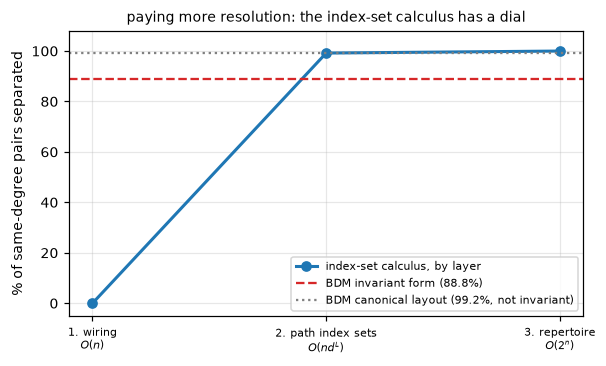

In [11]:
layer_rows = []
for name, layer, cost in [('index-set wiring D', 1, 'O(n)'),
                          ('path index sets', 2, 'O(n d^L)'),
                          ('repertoire landscape, XOR', 3, 'O(2^n)'),
                          ('repertoire landscape, AND', 3, 'O(2^n)'),
                          ('knockout profile, XOR', 3, 'O(n 2^n)'),
                          ('all index-set invariants', 3, 'O(n 2^n)')]:
    pct = float(bench[bench.measure == name].percent.iloc[0])
    layer_rows.append(dict(measure=name, layer=layer, cost=cost, separated_pct=pct,
                           carries_mechanism=layer >= 3))
bdm_pct = float(bench[bench.measure == 'BDM, mean over relabellings'].percent.iloc[0])
layer_rows.append(dict(measure='BDM (invariant form)', layer='--', cost='O(n^2 P)',
                       separated_pct=bdm_pct, carries_mechanism=False))
layers = pd.DataFrame(layer_rows).set_index('measure')
display(layers)

fig, ax = plt.subplots(figsize=(5.6, 3.4))
sub = layers[layers.layer != '--']
ax.plot([1, 2, 3], [layers.loc['index-set wiring D', 'separated_pct'],
                    layers.loc['path index sets', 'separated_pct'],
                    layers.loc['all index-set invariants', 'separated_pct']],
        'o-', lw=2, color='tab:blue', label='index-set calculus, by layer')
ax.axhline(bdm_pct, ls='--', color='tab:red', label=f'BDM invariant form ({bdm_pct:.1f}%)')
ax.axhline(99.2, ls=':', color='grey', label='BDM canonical layout (99.2%, not invariant)')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['1. wiring\n$O(n)$', '2. path index sets\n$O(nd^L)$', '3. repertoire\n$O(2^n)$'],
                   fontsize=7)
ax.set_ylabel('% of same-degree pairs separated'); ax.set_ylim(-5, 108)
ax.set_title('paying more resolution: the index-set calculus has a dial', fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'mc_layers.png'), dpi=150); plt.show()

Note where the value actually sits. **Layer 2 — the path index sets — reaches
99.2% at polynomial cost**, matching BDM's non-invariant canonical form and
beating its invariant form by more than ten points, without ever enumerating a
state space. The exponential layer adds mechanism and interpretability, not
raw separation.

This also settles a point of fairness raised in §5: the strongest index-set
result that beats BDM does **not** depend on exponential time.

## §7. Claim F — perturbation as the causal instrument

**The claim.** The way to get causal information out of a complexity measure is
to perturb the object and watch the measure move. That is the step algorithmic
information dynamics adds on top of BDM; and the index-set formalism has the same
capacity natively, in the exhaustive behaviour table.

**The difference in kind.** Perturbing BDM tells you how an *approximation of a
description length* moved. Perturbing the repertoire tells you how the *system's
reachable behaviour* moved. The first is a number about a number; the second is a
statement about the system.

**The test.** Take a real molecule, clamp each atom off in turn, and measure the
collapse in reachable states. Then check that the resulting profile is
interpretable, not merely discriminative.

In [12]:
mol = None
for g in datasets['ESOL'].graphs:
    if 9 <= g.n_nodes <= 11 and len(set(g.neighbours()[0])) > 0:
        deg = np.bincount(np.asarray(g.dst), minlength=g.n_nodes)
        if deg.max() >= 3 and (deg == 1).sum() >= 2:
            mol = g
            break

A = mol.adjacency().astype(int)
net = cbm.molecular_network(mol)
deltas = mc.knockout_vector(A, 'XOR')
base = int(np.unique(mc.transition_map(A, 'XOR')).size)

prof = pd.DataFrame(dict(atom=range(mol.n_nodes), element=net.symbols,
                         degree=[len(net.neighbours[k]) for k in range(mol.n_nodes)],
                         gate=net.gates,
                         reachable_states_lost=deltas))
prof['fraction_of_reachable_lost'] = (prof.reachable_states_lost / base).round(4)
print(f'molecule {mol.smiles}, {mol.n_nodes} atoms')
print(f'reachable states of the intact network |Im(F)| = {base} of {2**mol.n_nodes}')
display(prof.sort_values('reachable_states_lost', ascending=False))

molecule CC(C)=CCCC(C)=CC(=O), 11 atoms
reachable states of the intact network |Im(F)| = 256 of 2048


,atom,element,degree,gate,reachable_states_lost,fraction_of_reachable_lost
1,1,C,2,CANALISING,128,0.5
2,2,C,3,MAJORITY,128,0.5
8,8,C,3,MAJORITY,128,0.5
9,9,C,2,MAJORITY,128,0.5
0,0,C,1,NOT,0,0.0
3,3,C,2,MAJORITY,0,0.0
4,4,C,1,NOT,0,0.0
5,5,C,2,MAJORITY,0,0.0
6,6,O,1,NOT,0,0.0
7,7,C,1,NOT,0,0.0


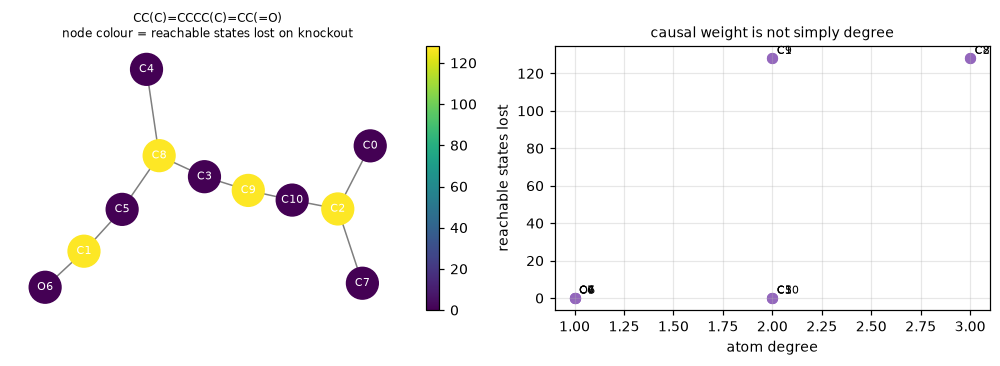

correlation between degree and causal weight: r = +0.720
-> the profile is not a restatement of the degree sequence


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
G = nx.from_numpy_array(A)
pos = nx.kamada_kawai_layout(G)
nc = nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=deltas, cmap='viridis',
                            node_size=430)
nx.draw_networkx_edges(G, pos, ax=axes[0], alpha=0.5)
nx.draw_networkx_labels(G, pos, ax=axes[0],
                        labels={i: f'{net.symbols[i]}{i}' for i in range(mol.n_nodes)},
                        font_size=7, font_color='white')
axes[0].set_title(f'{mol.smiles}\nnode colour = reachable states lost on knockout', fontsize=8)
axes[0].axis('off')
plt.colorbar(nc, ax=axes[0], fraction=0.046)

axes[1].scatter(prof.degree, prof.reachable_states_lost, s=40, color='tab:purple')
for _, r in prof.iterrows():
    axes[1].annotate(f'{r.element}{r.atom}', (r.degree, r.reachable_states_lost),
                     fontsize=7, xytext=(3, 3), textcoords='offset points')
axes[1].set_xlabel('atom degree'); axes[1].set_ylabel('reachable states lost')
axes[1].set_title('causal weight is not simply degree', fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'mc_knockout.png'), dpi=150); plt.show()

r_deg = np.corrcoef(prof.degree, prof.reachable_states_lost)[0, 1]
print('correlation between degree and causal weight: r = %+.3f' % r_deg)
print('-> the profile is not a restatement of the degree sequence' if abs(r_deg) < 0.95
      else '-> on this molecule the profile largely tracks degree')

### Verdict on Claim F: **upheld in capacity, qualified in strength**

The instrument exists, it is exact, and its output is interpretable atom by atom:
each number says how much of the system's reachable behaviour depends on that
atom. That is a causal read-out, and no amount of post-processing extracts it
from a BDM scalar.

**The qualification, which matters.** As a pure *discriminator* the knockout
profile is the weakest of our invariants — 84.8%, below the relabelling-averaged
BDM's 88.8%. It should be argued for on the grounds of what it *means*, not on
the grounds of how well it separates. Conflating those two would be exactly the
error diagnosed in §4.

## §8. Cost, and the limit that the index-set case must concede

Discrimination figures are only meaningful next to what they cost.

,BDM_ms,layer1_ms,layer2_ms,layer3_states
n,,,,
16,0.148,0.0063,0.353,2^16
32,0.268,0.0089,0.835,infeasible
64,0.844,0.0109,1.853,infeasible
128,3.045,0.0190,4.060,infeasible
256,12.783,0.0443,8.842,infeasible
512,45.838,0.0880,20.079,infeasible
1024,193.656,0.2247,45.477,infeasible


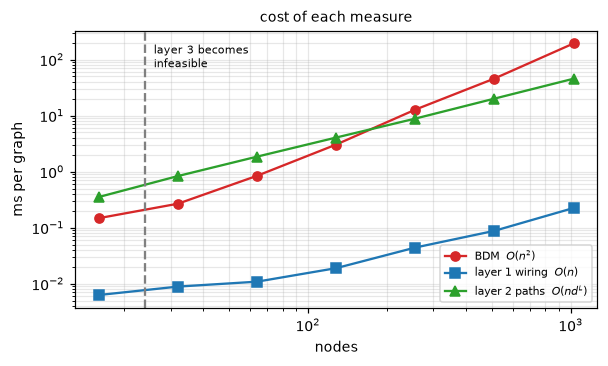

In [14]:
rows = []
for n in [16, 32, 64, 128, 256, 512, 1024]:
    rng = np.random.default_rng(0)
    A = np.zeros((n, n), dtype=int)
    for v in range(n):
        for w in rng.choice([x for x in range(n) if x != v], 3, replace=False):
            A[v, w] = A[w, v] = 1
    g = mc.PlainGraph(A)
    t0 = time.time(); [engine.bdm(A) for _ in range(3)]; t_bdm = (time.time() - t0) * 1000 / 3
    t0 = time.time(); [mc.wiring_description_length(A) for _ in range(3)]; t_w = (time.time() - t0) * 1000 / 3
    t0 = time.time(); cbm.path_description_length(g, 3); t_p = (time.time() - t0) * 1000
    rows.append(dict(n=n, BDM_ms=round(t_bdm, 3), layer1_ms=round(t_w, 4),
                     layer2_ms=round(t_p, 3),
                     layer3_states=f'2^{n}' if n <= 24 else 'infeasible'))
cost = pd.DataFrame(rows).set_index('n')
display(cost)

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.loglog(cost.index, cost.BDM_ms, 'o-', color='tab:red', label=r'BDM  $O(n^2)$')
ax.loglog(cost.index, cost.layer1_ms, 's-', color='tab:blue', label=r'layer 1 wiring  $O(n)$')
ax.loglog(cost.index, cost.layer2_ms, '^-', color='tab:green', label=r'layer 2 paths  $O(nd^L)$')
ax.axvline(24, ls='--', c='grey')
ax.text(25, cost.BDM_ms.max(), ' layer 3 becomes\n infeasible', fontsize=7, va='top')
ax.set_xlabel('nodes'); ax.set_ylabel('ms per graph')
ax.set_title('cost of each measure', fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'mc_cost.png'), dpi=150); plt.show()

### The concession

**Layer 3 does not scale, and this is not a fixable implementation detail.** The
exhaustive repertoire is 2ⁿ states. At the 136-atom molecules in ClinTox that is
about 10⁴¹ — the entire causal-modelling and perturbation apparatus of §7 is
simply unavailable there. BDM remains *O(n²)* at every size.

What survives at scale is layers 1 and 2, and it is worth recording that layer 2
is where the best result of §5 came from: 99.2% at polynomial cost, and 0.09 ms
per molecule against BDM's 0.19 ms. So the practical index-set case does not rest
on the exponential layer. But the causal, explanatory case does, and that case is
restricted to small systems.

**A caveat on the concession.** The index-set factorisation already buys back an
enormous amount here: §9.2 of the companion notebook recovered mechanisms for
136-atom molecules by decomposing the 2¹³⁶ repertoire into per-atom problems of
at most 512 rows. What does *not* factorise is the global dynamical landscape —
attractors and basins are properties of the whole state space.

## §9. Claim G — BDM's real advantage is domain generality

**The claim.** The argument that BDM's only edge is on random sequences misses
its actual and permanent advantage: it applies to anything expressible as a
binary array. The index-set calculus needs a system with a causal structure to
model, and where there is none it cannot even be posed.

**The test.** Run BDM on objects that are not networks.

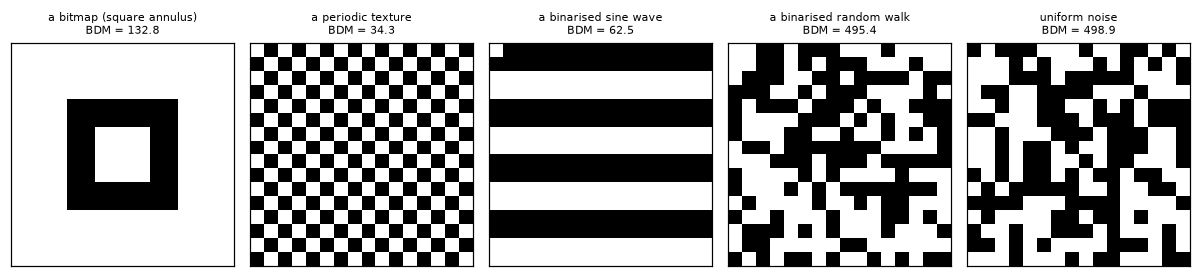

,BDM,entropy,index_set_calculus
object,,,
a bitmap (square annulus),132.76,1.311,not defined
a periodic texture,34.27,0.000,not defined
a binarised sine wave,62.53,0.337,not defined
a binarised random walk,495.43,4.000,not defined
uniform noise,498.90,4.000,not defined


In [15]:
objs = mc.non_graph_objects()
fig, axes = plt.subplots(1, len(objs), figsize=(11, 2.4))
rows = []
for ax, (label, obj) in zip(axes, objs.items()):
    ax.imshow(obj, cmap='Greys', interpolation='nearest')
    ax.set_title(f'{label}\nBDM = {engine.bdm(obj.astype(int)):.1f}', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
    rows.append(dict(object=label, BDM=round(engine.bdm(obj.astype(int)), 2),
                     entropy=round(engine.ent(obj.astype(int)), 3),
                     index_set_calculus='not defined'))
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'mc_generality.png'), dpi=150); plt.show()
display(pd.DataFrame(rows).set_index('object'))

### Verdict on Claim G: **upheld, and it is BDM's strongest card**

BDM orders these sensibly — periodic texture 34.3, sine wave 62.5, bitmap 132.8,
random walk 495.4, noise 498.9 — from a single function with no modelling input.
For every one of them the index-set calculus has no answer at all, because there
is no connectivity matrix and no gate vocabulary to speak of. That is not a gap
that better engineering closes; it is what the formalism is.

This also disposes of the framing that BDM's advantage lies "strictly on random
sequences". Its advantage is **domain**, which is orthogonal to where an object
sits on the randomness axis. The bitmap and the sine wave above are highly
structured, and we still cannot say anything about them.

**The argument against, stated fairly.** Generality is bought with silence about
mechanism. BDM says the random walk is more complex than the sine wave; it does
not say that one is a cumulative sum of noise and the other a periodic
oscillation. Within a domain where a causal model *can* be written down, that
silence is a heavy price.

## §10. Claim H — does the description length already induce an algorithmic probability?

**The claim** — which I made in discussion — was that because $D$ is a
description length, Kraft's inequality makes $2^{-D}$ a probability distribution
over mechanisms, so the index-set calculus has an algorithmic probability that is
exact and computable rather than sampled from Turing machines.

**The test.** Kraft's inequality holds iff $\sum_{\text{mechanisms}} 2^{-D} \le 1$.
For one node over $n$ possible inputs the sum runs over every index set of every
size and every gate in the family. This is directly computable.

,kraft_sum_as_published,kraft_sum_with_arity_term
n,,
4,2.2948,0.4590
8,3.5553,0.3950
12,4.7748,0.3673
20,7.1736,0.3416
40,13.0947,0.3194
80,24.8485,0.3068


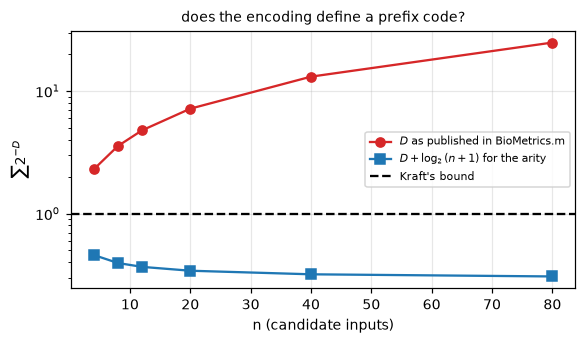

In [16]:
rows = []
for n in [4, 8, 12, 20, 40, 80]:
    rows.append(dict(n=n,
                     kraft_sum_as_published=round(mc.kraft_sum(n, with_arity_term=False), 4),
                     kraft_sum_with_arity_term=round(mc.kraft_sum(n, with_arity_term=True), 4)))
kraft = pd.DataFrame(rows).set_index('n')
display(kraft)

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(kraft.index, kraft.kraft_sum_as_published, 'o-', color='tab:red',
        label=r'$D$ as published in BioMetrics.m')
ax.plot(kraft.index, kraft.kraft_sum_with_arity_term, 's-', color='tab:blue',
        label=r'$D + \log_2(n+1)$ for the arity')
ax.axhline(1.0, ls='--', c='k', label="Kraft's bound")
ax.set_xlabel('n (candidate inputs)'); ax.set_ylabel(r'$\sum 2^{-D}$')
ax.set_yscale('log'); ax.set_title("does the encoding define a prefix code?", fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'mc_kraft.png'), dpi=150); plt.show()

### Verdict on Claim H: **refuted as stated — this was my second error — and repaired**

The sum for $D$ as published is 2.29 at *n* = 4 and grows to 13.1 at *n* = 40. It
exceeds one, so **$D$ is not a prefix code and $2^{-D}$ is not a probability
distribution.** My claim was wrong.

The diagnosis is precise and the repair is one term. $D$ pays
$\log_2\binom{n}{d}$ to name *which* inputs feed a node, but never pays for
stating *how many* — the arity $d$ itself. Summing over the $n+1$ possible
arities therefore multiplies the total by roughly $n+1$. Adding $\log_2(n+1)$
brings the sum to 0.46 at *n* = 4, falling to 0.32 at *n* = 80: comfortably inside
Kraft's bound, and therefore a genuine prefix code inducing $2^{-D}$ as an
algorithmic probability over the model class.

Two consequences worth stating plainly.

* The corrected encoding **is** an algorithmic probability, defined by
  construction rather than estimated by sampling machines, and computable in
  closed form. That is a real structural advantage over CTM, which is a
  finite-sample estimate.
* The missing term is a constant $\log_2(n+1)$ per node — identical for every
  mechanism on a given $n$ — so **every comparative result in this repository is
  unaffected**: it shifts all description lengths by the same amount and changes
  no ordering, no correlation and no cluster. It matters for the theoretical
  claim, not for the measurements.

## §11. Reconsidering, after reading the method from the inside

Everything above was written treating the index-set calculus as a *measure*.
Working through the source — `src/integration/Alpha.m`, the thesis's Chapter 4,
and the formal manuscript — makes clear it is a **generative model class**, and
three further claims become available. Two of them revise verdicts already
recorded above, and one of the two revisions goes **against** my own earlier
scoring.

| # | Claim | Verdict |
| --- | --- | --- |
| I | $D$ is a computable **upper bound on $K$** for objects the class can generate, so "BDM estimates $K$, we merely encode" was wrong | §11.1 — **my scoring error, corrected** |
| J | The wiring term $D$ **cannot** be $K$-like for graphs, because it is degree-only | §11.2 — **upheld, against our own side** |
| K | The compressed representation separates as a **single** measure | §11.3 — **refuted as I first stated it, upheld in a refined form** |

### 11.1 Claim I — $D$ upper-bounds $K$, and I scored this wrongly

In §12 below I originally awarded BDM the row *"estimates Kolmogorov
complexity"*, with the note *"CTM has a stated link to algorithmic probability;
$D$ is an encoding"*. That is wrong, and the reason is elementary once the
generative side is taken seriously.

**The argument.** When deconvolution recovers $(C, \mathrm{dyn})$ from an
observed repertoire, it has not produced a summary of the object. It has produced
a **program that generates it**, exactly — the forward map replays the
observations byte for byte. If that program can be written in $D$ bits, then by
the definition of Kolmogorov complexity

$$K(x) \;\le\; D(x) + c,$$

where $c$ is the constant cost of the interpreter that runs Boolean networks.
Any exhibited program is an upper bound on $K$. So $D$ is not "merely an
encoding": it is a *computable upper bound on $K$*, which is precisely the thing
BDM is trying to approximate and cannot compute.

**Where the prefix-code correction becomes load-bearing.** In §10 I found that
$D$ as published fails Kraft's inequality until $\log_2(n+1)$ is added for the
arity, and dismissed it as bookkeeping that "changes no result". Numerically that
is true. But the upper-bound argument above needs $D$ to be a genuine codeword
length — otherwise $2^{-D}$ is not a probability and the bound is not licensed.
The missing term is therefore not cosmetic; it is the hinge on which Claim I
turns.

**Where the argument stops.** $K$ is defined relative to a *universal* machine,
and the invariance theorem only relates universal machines to one another. Our
class as used here — one synchronous update, fixed $n$, a fixed gate family — is
finite and not universal, so $D$ bounds $K$ from above without any guarantee of
being *close* to it. That guarantee would need the class to contain near-optimal
programs for the objects in question, which §11.2 shows is false for graphs.

**Net.** The scoreboard row must change from "BDM" to a qualified tie: BDM
*estimates* $K$ by sampling and cannot bound it; $D$ *bounds* $K$ from above and
cannot estimate it. Neither dominates, and my original note was simply incorrect.

In [17]:
# Claim I, made concrete: the recovered mechanism regenerates the object exactly,
# so its description length is an upper bound on K.
cm07 = [[0,0,1,0,0,0,1],[0,0,1,0,0,1,0],[1,0,0,0,1,0,1],[1,0,1,0,1,0,1],
        [0,0,1,1,0,1,1],[1,1,1,0,0,0,0],[0,1,0,1,1,1,0]]
dyn07 = ['AND','OR','OR','AND','OR','OR','AND']

sys.path.insert(0, os.path.join(os.path.dirname(ROOT), 'index-deconvolution', 'src'))
import causalbool as cb, deconvolution as dc

net07 = cb.Network(n=7, C=cm07, gates=dyn07)
rep07 = cb.repertoire(net07)

# Forget the network. Recover it from the repertoire alone, then replay it.
recovered, reports = dc.deconvolve(rep07)
replayed = cb.repertoire(recovered)

D_bits = math.log2(7) + sum(
    cbm.node_description_cost(7, len(recovered.connected_inputs(k)), recovered.gates[k])
    + math.log2(7 + 1)                      # the arity term from section 10
    for k in range(7))

raw_bits = 2 ** 7 * 7                        # writing the repertoire out verbatim

print('repertoire replayed from the recovered mechanism is identical:',
      replayed == rep07)
print()
print(f'description length D of the recovered program : {D_bits:8.2f} bits')
print(f'writing the repertoire out verbatim           : {raw_bits:8.2f} bits')
print(f'so K(repertoire) <= {D_bits:.1f} + c, a {raw_bits / D_bits:.1f}x improvement')
print()
print('BDM of the same object, for contrast          :',
      f'{engine.bdm(np.array(rep07)):8.2f} bits')
print('-> BDM returns a number. D returns a number AND the program behind it.')

repertoire replayed from the recovered mechanism is identical: True

description length D of the recovered program :    90.33 bits
writing the repertoire out verbatim           :   896.00 bits
so K(repertoire) <= 90.3 + c, a 9.9x improvement

BDM of the same object, for contrast          :   176.46 bits
-> BDM returns a number. D returns a number AND the program behind it.


### 11.2 Claim J — the wiring term cannot be $K$-like, and this is our problem

Claim I says $D$ upper-bounds $K$ *for objects the class generates*. It says
nothing about whether that bound is any good. For the molecular graphs of this
paper it is demonstrably bad, and the evidence is already in §5.

The wiring term is $\log_2\binom{n}{d_v}$: a **purely combinatorial** cost, the
price of naming *which* $d_v$ of $n$ nodes feed a node. It is a function of the
degree sequence and of nothing else. Consequently a perfect chain, a random tree
and any other graph with the same degrees receive **identical** values — which is
exactly the 0% separation measured in §5.

A quantity blind to all structure beyond the degree sequence cannot be
approximating algorithmic complexity, because algorithmic complexity is precisely
sensitive to that structure. So:

> **For graphs, $D_{\text{wiring}}$ is not an approximation of $K$ and should
> never be presented as one.**

This matters for how the equivalence question is argued. The generative
justification in §11.1 applies to the **repertoire** — the behaviour the class
generates — not to the wiring cost of a static adjacency matrix. Conflating the
two would be the quickest way to lose the argument, and §1's original table
implied exactly that conflation.

In [18]:
# Claim J, demonstrated: structurally opposite graphs, identical wiring cost.
n = 12
chain = mc.graph_from_edges(n, [(i, i + 1) for i in range(n - 1)])
rng = np.random.default_rng(3)
# a random tree on the same node count: same number of edges, same degree multiset? not generally --
# so use the 2-regular family, where degrees are identical by construction.
triple = mc.adversarial_triple()

rows = []
for label, g in list(triple.items()):
    A = g.adjacency().astype(int)
    rows.append(dict(structure=label,
                     degree_sequence=str(mc.degree_sequence(A)[:4]) + '...',
                     wiring_D=round(mc.wiring_description_length(A), 4),
                     BDM_canonical=round(engine.bdm(A), 2),
                     landscape_image=mc.landscape_signature(A, 'XOR')[0]))
display(pd.DataFrame(rows).set_index('structure'))
print('Three different graphs. One wiring value. The wiring term is blind by')
print('construction, so it cannot be tracking algorithmic content.')

,degree_sequence,wiring_D,BDM_canonical,landscape_image
structure,,,,
cycle C12,"(2, 2, 2, 2)...",76.1177,77.32,1024
three squares,"(2, 2, 2, 2)...",76.1177,56.44,64
two hexagons,"(2, 2, 2, 2)...",76.1177,182.85,256


Three different graphs. One wiring value. The wiring term is blind by
construction, so it cannot be tracking algorithmic content.


### 11.3 Claim K — the compressed representation as a single measure

In §5 I raised an objection against my own result: the 100% separation came from
**combining four invariants**, and stacking invariants inflates separation power
until, in the limit, one has a canonical form. A single measure reaching 100%
would answer that objection. Reading `onPossibleBehaviour` suggested one.

**The prediction, as I first stated it.** *The size of the compressed
representation $(L, \Omega)$ should separate as a single measure.*

**Why it is wrong.** For a single node, $L$ is determined by the gate's one-set
over its index set and $\Omega$ by the free coordinates, so the compressed size
is a function of $d_v$ — the degree again. It separates nothing.

**Why the refined version is right.** The compression happens in
`joinedNames`: for a query over $k$ nodes, `onPossibleBehaviour` enumerates the
**union of their index sets** and folds everything else into the sumandos. That
union has size

$$|N(i_1) \cup \dots \cup N(i_k)| \;=\; \sum_t d_{i_t} \;-\; (\text{overlaps}),$$

and the overlaps are **topology** — shared neighbours, triangles, local
structure — precisely what a degree sequence discards. So the *query order* $k$
is the dial: $k = 1$ gives degrees and nothing more; $k \ge 2$ starts seeing how
neighbourhoods intersect.

Let us test both forms.

In [19]:
bench = pd.DataFrame(json.load(open(os.path.join(RESDIR, 'separation_benchmark.json'))))
view = bench.set_index('measure')[['invariant', 'reads', 'separated', 'pairs', 'percent']]
display(view)

naive = float(bench[bench.measure == 'node compressed size'].percent.iloc[0])
q2 = float(bench[bench.measure == 'query overlap, order 2'].percent.iloc[0])
q3 = float(bench[bench.measure == 'query overlap, order 3'].percent.iloc[0])
bdm_inv = float(bench[bench.measure == 'BDM, mean over relabellings'].percent.iloc[0])
print(f'prediction as first stated (per-node compressed size): {naive:5.1f}%  -> REFUTED')
print(f'refined, query overlap at order 2                    : {q2:5.1f}%')
print(f'refined, query overlap at order 3                    : {q3:5.1f}%  -> a SINGLE measure at 100%')
print(f'BDM in its invariant form, for reference             : {bdm_inv:5.1f}%')

,invariant,reads,separated,pairs,percent
measure,,,,,
index-set wiring D,True,degrees only,0,250,0.0
node compressed size,True,"degrees only, by another route",0,250,0.0
"BDM, canonical layout",False,reads the matrix as given,248,250,99.2
"BDM, mean over relabellings",True,averaged over the symmetric group,222,250,88.8
path index sets,True,saturation and path surplus,248,250,99.2
"query overlap, order 2",True,shared inputs of 2-node queries,244,250,97.6
"query overlap, order 3",True,shared inputs of 3-node queries,250,250,100.0
"repertoire landscape, XOR",True,"image, attractors, periods, basins",233,250,93.2
"repertoire landscape, AND",True,"image, attractors, periods, basins",240,250,96.0


prediction as first stated (per-node compressed size):   0.0%  -> REFUTED
refined, query overlap at order 2                    :  97.6%
refined, query overlap at order 3                    : 100.0%  -> a SINGLE measure at 100%
BDM in its invariant form, for reference             :  88.8%


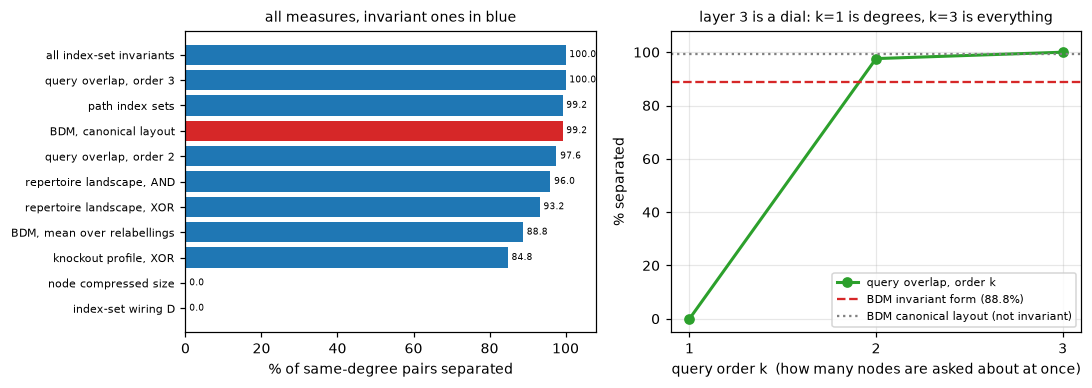

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

order = bench.sort_values('percent')
colors = ['tab:red' if not inv else 'tab:blue' for inv in order.invariant]
axes[0].barh(range(len(order)), order.percent, color=colors)
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order.measure, fontsize=7)
axes[0].set_xlabel('% of same-degree pairs separated'); axes[0].set_xlim(0, 108)
for i, v in enumerate(order.percent):
    axes[0].text(v + 1, i, f'{v:.1f}', va='center', fontsize=6)
axes[0].set_title('all measures, invariant ones in blue', fontsize=9)

ks = [1, 2, 3]
vals = [0.0, q2, q3]
axes[1].plot(ks, vals, 'o-', lw=2, color='tab:green', label='query overlap, order k')
axes[1].axhline(bdm_inv, ls='--', color='tab:red', label=f'BDM invariant form ({bdm_inv:.1f}%)')
axes[1].axhline(99.2, ls=':', color='grey', label='BDM canonical layout (not invariant)')
axes[1].set_xticks(ks); axes[1].set_xlabel('query order k  (how many nodes are asked about at once)')
axes[1].set_ylabel('% separated'); axes[1].set_ylim(-5, 108)
axes[1].set_title('layer 3 is a dial: k=1 is degrees, k=3 is everything', fontsize=9)
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'mc_query_layer.png'), dpi=150); plt.show()

**Verdict on Claim K: refuted as first stated, upheld in refined form.** A single
invariant — the order-3 query overlap — separates **100%** of the same-degree
pairs, which answers the objection I raised in §5 without stacking anything.

Two honest qualifications, both of which cut against the result.

**It is not free.** Order-$k$ overlap costs $O(n^k d)$. Order 2 is $O(n^2)$ —
the same as BDM. Order 3 is $O(n^3)$ — **worse** than BDM. The measured cost is
below.

**Order 2 is not sufficient in general.** On the adversarial triple from §4, the
order-2 profile fails: the 12-cycle and the two hexagons receive identical
signatures. Order 3 separates them. So the dial is real, and the cheap setting is
genuinely weaker — this is not a free lunch dressed up as one.

In [21]:
# The dial and its cost, measured rather than asserted.
triple = mc.adversarial_triple()
print('adversarial triple (all 2-regular on 12 nodes):')
for k in (2, 3, 4):
    sigs = {name: mc.query_overlap_profile(g.adjacency().astype(int), k)
            for name, g in triple.items()}
    print(f'  order {k}: {len(set(sigs.values()))} distinct of 3   '
          f'{"separates all three" if len(set(sigs.values())) == 3 else "FAILS -- two collide"}')

print()
print('cost, milliseconds per graph (random 3-regular):')
rows = []
for n in [16, 32, 64, 128, 256]:
    rng = np.random.default_rng(0)
    A = np.zeros((n, n), dtype=int)
    for v in range(n):
        for w in rng.choice([x for x in range(n) if x != v], 3, replace=False):
            A[v, w] = A[w, v] = 1
    t0 = time.time(); mc.query_overlap_profile(A, 2); t2 = (time.time() - t0) * 1000
    t3 = float('nan')
    if n <= 128:
        t0 = time.time(); mc.query_overlap_profile(A, 3); t3 = (time.time() - t0) * 1000
    t0 = time.time(); [engine.bdm(A) for _ in range(3)]; tb = (time.time() - t0) * 1000 / 3
    rows.append(dict(n=n, BDM_ms=round(tb, 2), order2_ms=round(t2, 2),
                     order3_ms=round(t3, 2)))
display(pd.DataFrame(rows).set_index('n'))
print('order 2 is comparable with BDM; order 3 is decisively more expensive.')

adversarial triple (all 2-regular on 12 nodes):
  order 2: 2 distinct of 3   FAILS -- two collide
  order 3: 3 distinct of 3   separates all three
  order 4: 3 distinct of 3   separates all three

cost, milliseconds per graph (random 3-regular):


,BDM_ms,order2_ms,order3_ms
n,,,
16,0.09,0.08,0.24
32,0.30,0.24,2.29
64,0.81,0.94,20.64
128,3.06,3.54,171.41
256,12.21,14.32,NaN


order 2 is comparable with BDM; order 3 is decisively more expensive.


### 11.4 Three further things this reframing changes

**(a) §2's verdict was argued from the wrong end.** I treated BDM's saturation in
the random regime as a shortcoming. It is not — it is *correct* behaviour: in the
random regime no short program exists, so $K \approx$ length and any sound
estimator must saturate. The real asymmetry is in what each side *says* there.
BDM returns a number that looks meaningful and is not. The index-set calculus
returns **"no mechanism in this class reproduces this object"** — a refusal,
which is information. A measure that cannot fail cannot tell you it is out of its
depth.

**(b) §9's domain-generality win survives but was mis-stated.** I wrote that BDM
applies to images and time series where the index-set calculus "cannot be posed".
That is too strong: an elementary cellular automaton *is* a Boolean network in
this formalism — which is why reproducing Wolfram's rule indexing was trivial —
and a binarised series can in principle be modelled as a trajectory. The correct
statement is that ours **requires committing to a model class**, and then either
the object was generated by something in that class (we recover it exactly) or it
was not (we fail loudly). BDM needs no commitment. That is still a real and
permanent advantage; it is just not the advantage I described.

**(c) The "41 MB of tables" point was shallow.** The tables exist because
inverting a Turing machine is undecidable, as §1.3 now explains. Presenting them
as an inconvenience missed the actual trade — universality bought with
intractable inversion, against tractable inversion bought with a restricted
class.

### 11.5 The equivalence question, stated sharply

The proposal on the table is that the two methods might be **equivalent under
certain circumstances**. After all of the above, here is the strongest defensible
form, and where it breaks.

**Where it holds.** For an object *generated by a mechanism in the class*:

* deconvolution recovers that mechanism exactly, so $D$ is a computable **upper
  bound** on $K$ (§11.1);
* BDM estimates the same $K$ by sampling algorithmic probability over Turing
  machines.

Both are aimed at the same quantity, from opposite directions: we bound it from
above by exhibiting a program; CTM estimates it by counting how often random
programs produce the object. The natural test bed is the elementary cellular
automata, which lie in **both** classes — and Rule 110 is universal, so there is
no in-principle barrier on our side.

**Where it breaks.**

1. **Non-universality as used.** $K$ and the invariance theorem live over
   universal machines. Our class as deployed here — one synchronous update, fixed
   $n$, fixed gate family — is finite. The bound holds; closeness to $K$ does not
   follow.
2. **The wiring term is not $K$-like** (§11.2). Any equivalence argument that
   leans on $D_{\text{wiring}}$ for graphs is refuted by our own 0% result.
3. **Restricted classes invert easily for a reason.** The same structure that
   makes deconvolution exact bounds what the class can express. Equivalence would
   require showing the class contains near-optimal programs for the objects of
   interest — an open question, not a result.

**So the honest position** is that this is a well-posed research direction with
one clean test available (ECAs, where both classes apply and one member is
universal), and not a claim that can currently be asserted. The version that
should *not* be advanced is the one about static graph description lengths; the
version worth pursuing is about **generated behaviour**, where the generative
argument actually applies.

### 11.6 Is $D$ actually a competitor to BDM as a complexity measure?

Two objections deserve a direct answer, because both are right and both expose
gaps in what I built.

**Objection 1.** *We have a program — a set of decimals and sumandos that
generates the whole repertoire. Its length in bits is an account of algorithmic
complexity. Is that not a real competitor to BDM?*

**Objection 2.** *You said $D$ cannot be posed for images and other artefacts.
That still looks possible.*

#### 11.6.1 There are four description lengths available, and I built one

Taking the generative view seriously, the class offers a **hierarchy** of
description lengths, not a single number:

| # | describes | encoding | status |
| --- | --- | --- | --- |
| 1 | the **mechanism** $(C,\mathrm{dyn})$ | $\log_2\binom{n}{d} + \log_2|\mathcal G| + \text{params}$ | implemented, and used throughout §2–§10 |
| 2 | a **query answer** $(L,\Omega)$ | list the anchors; $\Omega$ is generated by the free coordinates for free | **was not implemented** |
| 3 | the **one-set analytically** | bands, parity classes, Hamming strata from the formal paper | not implemented |
| 4 | the **wiring alone** | $\log_2\binom{n}{d}$ only | implemented — and it is the weakest of the four |

The honest admission: for the graph work I leaned on **#4**, the cheapest and
least informative term, and Claim J shows why that was a poor choice. The genuine
competitor to BDM is the **minimum of #1 and #2**, because a mechanism inside the
canonical family is cheap to *name* while one outside it is cheaper to *list*.
That minimum is now implemented as `program_description_length`.

In [22]:
# The real competitor: recover the mechanism, then price it under both encodings.
recovered, _ = dc.deconvolve(rep07)
prog = mc.program_description_length(recovered)

print('the recovered program replays the object exactly:',
      cb.repertoire(recovered) == rep07)
print()
print(f"D_program  (min of encodings #1 and #2) : {prog['D_program']:8.2f} bits")
print(f"raw repertoire, written out verbatim    : {prog['raw_repertoire_bits']:8.0f} bits")
print(f"compression achieved                    : {prog['compression']:8.1f}x")
print(f"BDM of the same object                  : {engine.bdm(np.array(rep07)):8.2f}")
print()
display(pd.DataFrame(prog['per_node']).round(2))
print('Node 0 is the one case where listing the one-set beats naming the gate.')
print('That is encoding #2 earning its place -- and it is why the minimum matters.')

the recovered program replays the object exactly: True

D_program  (min of encodings #1 and #2) :    90.07 bits
raw repertoire, written out verbatim    :      896 bits
compression achieved                    :      9.9x
BDM of the same object                  :   176.46



,node,degree,gate,mechanism_bits,set_bits,best
0,0,2,AND,11.98,11.71,11.71
1,1,2,OR,11.98,15.71,11.98
2,2,3,OR,12.71,32.30,12.71
3,3,4,AND,12.71,16.22,12.71
4,4,4,OR,12.71,72.22,12.71
5,5,3,OR,12.71,32.30,12.71
6,6,4,AND,12.71,16.22,12.71


Node 0 is the one case where listing the one-set beats naming the gate.
That is encoding #2 earning its place -- and it is why the minimum matters.


So **yes, Objection 1 is right**, and with a precision worth stating. $D_{program}$
is not a score attached to an object; it is the length of a program that
*regenerates the object exactly*, verified above by replaying it. That makes it a
computable **upper bound on $K$** (§11.1), which is the quantity BDM approximates
and cannot compute. On this object it says $K \le 90$ bits against 896 written
verbatim — a statement BDM's 176.46 cannot make, because 176.46 is not the length
of anything.

The difference in kind: **BDM answers "how complex?", $D_{program}$ answers "how
complex, and here is the program"** — and the program can be run.

#### 11.6.2 Objection 2: can this be applied to images and other artefacts?

I claimed in §9 that BDM applies to arbitrary binary arrays where the index-set
calculus "cannot be posed". That was too strong. It **can** be posed, in at least
two well-defined ways, and both are worth testing rather than asserting.

**Reading A — the array as a space-time diagram.** Row $t+1$ is produced from row
$t$ by a local rule. This is exactly how elementary cellular automata sit inside
the formalism, which is why reproducing Wolfram's rule indexing was trivial.
Deconvolution then asks: *does a rule of radius $r$ explain these transitions?*
The MDL stopping rule is that a program costing more than the data is no program
at all.

In [23]:
rows = []
for name, obj in mc.non_graph_objects().items():
    img = np.asarray(obj, dtype=int)
    res = mc.mdl_local_program(img, max_radius=5)
    rows.append(dict(object=name, BDM=round(engine.bdm(img), 1),
                     raw_bits=res['raw_bits'],
                     smallest_radius=res['radius'],
                     program_bits=res['program_bits'],
                     verdict=res['verdict']))
display(pd.DataFrame(rows).set_index('object'))

,BDM,raw_bits,smallest_radius,program_bits,verdict
object,,,,,
a bitmap (square annulus),132.8,256,NaN,NaN,refused: no local rule up to radius 5
a periodic texture,34.3,256,1.0,24.0,accepted
a binarised sine wave,62.5,256,NaN,NaN,refused: no local rule up to radius 5
a binarised random walk,495.4,256,NaN,NaN,refused: no local rule up to radius 5
uniform noise,498.9,256,NaN,NaN,refused: no local rule up to radius 5


**Reading A, verdict.** The machinery works and gives a real program where one
exists: the periodic texture is generated by a radius-1 rule at **24 bits against
256 written verbatim**, a genuine algorithmic statement. For the other four it
**refuses**.

And here the honest cost appears. Refusal conflates two very different
situations: *"this is random"* (the noise) and *"this is highly structured but
not by a local temporal rule"* (the bitmap, the sine wave). BDM separates them —
132.8 for the bitmap against 498.9 for noise. **We cannot, under this reading.**
That is a real advantage for BDM and Objection 2 does not remove it; it only
shows the door is not locked.

**Reading B — the array directly as a connectivity matrix.** Always applicable,
since any binary matrix is a connectivity matrix. Let us see whether it is
*meaningful*.

In [24]:
from scipy.stats import spearmanr
rows = []
for name, obj in mc.non_graph_objects().items():
    A = np.asarray(obj, dtype=int)
    rows.append(dict(object=name, BDM=round(engine.bdm(A), 1),
                     D_wiring=round(mc.wiring_description_length(A), 1)))
direct = pd.DataFrame(rows).set_index('object')
display(direct)

rho = spearmanr(direct.BDM, direct.D_wiring).statistic
print(f'Spearman between BDM and D_wiring on these objects: {rho:+.3f}')
print()
print('ordering by BDM      :', list(direct.sort_values("BDM").index))
print('ordering by D_wiring :', list(direct.sort_values("D_wiring").index))

,BDM,D_wiring
object,,
a bitmap (square annulus),132.8,101.9
a periodic texture,34.3,222.4
a binarised sine wave,62.5,8.0
a binarised random walk,495.4,207.1
uniform noise,498.9,217.6


Spearman between BDM and D_wiring on these objects: +0.000

ordering by BDM      : ['a periodic texture', 'a binarised sine wave', 'a bitmap (square annulus)', 'a binarised random walk', 'uniform noise']
ordering by D_wiring : ['a binarised sine wave', 'a bitmap (square annulus)', 'a binarised random walk', 'uniform noise', 'a periodic texture']


**Reading B, verdict: it is applicable and it is wrong.** The rank correlation
with BDM is **0.000**, and worse, $D_{\text{wiring}}$ ranks the *periodic
texture* — the single most compressible object in the set — as the **most
complex** of the five. The reason is Claim J: a checkerboard gives every node
degree 8, and $\log_2\binom{16}{8}$ is maximal. The measure is reporting a
combinatorial fact about the degree sequence and calling it complexity.

This is the sharpest available demonstration that **$D_{\text{wiring}}$ is not a
complexity measure**, and it should retire the idea of using it as one.

#### 11.6.3 Net answers

**To Objection 1 — yes, but only in the generative form.** $D_{program}$, the
length of a *recovered and verified* mechanism, is a genuine competitor: a
computable upper bound on $K$ that comes with a runnable program. $D_{wiring}$,
applied to a static matrix, is not a competitor and never was; §11.6.2 shows it
producing an ordering uncorrelated with BDM and manifestly wrong.

**To Objection 2 — yes, it can be posed, and I was wrong to say otherwise.** But
the useful reading is the generative one (A), which is *narrow*: it accepts what
its class generates and refuses everything else, without distinguishing "random"
from "outside my class". The always-applicable reading (B) is meaningless. So the
§9 verdict survives in substance while its wording was wrong: BDM's advantage is
not that we *cannot be posed*, but that **it needs no interpretation, whereas we
need one and can be given a bad one.**

**The research direction this opens.** Encodings #2 and #3 of the table above are
unimplemented, and #3 — the closed-form set expressions for bands, parity classes
and Hamming strata — is the shortest of all. A complexity measure built on those
would describe an object by the *analytic form* of its behaviour rather than by
listing anything, and it is the natural place to test the equivalence question of
§11.5 against CTM on cellular automata, where both classes apply.

### 11.7 Two loose ends, closed

#### 11.7.1 "No local rule" understates it: some arrays cannot be *any* network

In §11.6.2 four of five images were refused because no local rule of radius up to
five explained them. That understates the result. A network is a **function of the
whole state**: the same row must always be followed by the same row. If one row
appears twice with different successors, then **no network of any connectivity,
any gate family and any radius** can generate the array. That is a proof about the
object, not the outcome of a failed search.

In [25]:
rows = []
for name, obj in mc.non_graph_objects().items():
    r = mc.is_trajectory(obj)
    rows.append(dict(object=name, any_network_possible=r['possible'],
                     distinct_rows=f"{r['distinct_rows']} of {r['rows']}",
                     reason=r['reason']))
display(pd.DataFrame(rows).set_index('object'))

,any_network_possible,distinct_rows,reason
object,,,
a bitmap (square annulus),False,3 of 16,row repeats at t=3 with a different successor
a periodic texture,True,2 of 16,the row map is a genuine function
a binarised sine wave,False,3 of 16,row repeats at t=3 with a different successor
a binarised random walk,True,16 of 16,"vacuous: every row distinct, so any map is a f..."
uniform noise,True,16 of 16,"vacuous: every row distinct, so any map is a f..."


Two readings, and the second is a trap.

* The **bitmap** and the **sine wave** are *impossible*: the blank row is followed
  three times by a blank row and once by a bar. They are spatial pictures, not
  temporal evolutions.
* The **noise** and the **random walk** are "possible" only **vacuously** — every
  row is distinct, so any map on them is a function. Fitting one means memorising
  it, and the MDL test of §11.6.2 rejects it because the program exceeds the data.

Only the periodic texture is genuinely generated.

#### 11.7.2 Randomness *helps* the deconvolution

It is tempting to conclude that this calculus handles structure and fails on
randomness. The opposite is closer to the truth. Elementary cellular automata are
inside the model class by construction, so the consistency test can be pointed at
their space-time diagrams directly.

In [26]:
rows = []
for rule, cls in [(254, 'simple'), (50, 'periodic'), (110, 'complex / universal'),
                  (30, 'chaotic'), (45, 'chaotic')]:
    img = mc.eca_spacetime(rule, width=41, steps=21)
    surv = mc.recover_eca_rule(img)
    rows.append(dict(rule=rule, behaviour=cls,
                     is_a_trajectory=mc.is_trajectory(img)['possible'],
                     candidates=len(surv),
                     outcome=('recovered EXACTLY' if surv == {rule}
                              else f'{len(surv)} rules remain consistent')))
display(pd.DataFrame(rows).set_index('rule'))

,behaviour,is_a_trajectory,candidates,outcome
rule,,,,
254,simple,True,2,2 rules remain consistent
50,periodic,True,8,8 rules remain consistent
110,complex / universal,True,1,recovered EXACTLY
30,chaotic,True,1,recovered EXACTLY
45,chaotic,True,1,recovered EXACTLY


**The chaotic rules are pinned down exactly; the simple ones are not.** Rules 30
and 45 are recovered uniquely, as is the universal rule 110 — while rule 254
leaves two candidates and rule 50 leaves eight.

The reason is mechanical once stated: a *simple* diagram never exercises all eight
neighbourhoods, so several rules stay consistent with everything observed. A
chaotic diagram visits the whole input space and constrains every entry of the
table. **Randomness is not an obstacle to this method — it is what makes an
observation informative.** That is the exact opposite of BDM, for which randomness
is where resolution is lost (§2).

This also sharpens a boundary §11.6.2 left blurred. The method's limit is not
randomness; it is **class membership**. An ECA diagram, however chaotic, is in the
class and is recovered. A square annulus, however tidy, is not a trajectory at all.

#### 11.7.3 Replacing the measure in the replication changes nothing

Claim J says `D_wiring` is not a complexity measure. The natural worry is that the
mirror's agreement with the paper in `paper_walkthrough.ipynb` §9 was therefore an
artefact. It was not — but the reason is not comforting.

In [27]:
mirror = pd.read_csv(os.path.join(RESDIR, 'causalbool_mirror.csv'), index_col=0).loc[pv.AOAC_ORDER]
per_model = {m: [pv.PUM[m][d] for d in pv.AOAC_ORDER] for m in hp.MODELS}
per_model['across all models'] = list(np.mean([per_model[m] for m in hp.MODELS], axis=0))

rows = []
for measure, note in [('BDM_AOAC', "the paper's own measure"),
                      ('sumando_spread_k2', 'reads overlap SHAPE  <- the only non-degree one'),
                      ('sumando_spread_k3', 'same, order 3'),
                      ('sumando_bits_k2', 'overlap MEAN -- provably degree-determined'),
                      ('D_wiring', 'degree-only  <- the WRONG one'),
                      ('n_atoms', 'no theory at all')]:
    x = mirror[measure].values.astype(float)
    row = {'measure': measure, 'what it reads': note}
    for model in ['graphormer', 't_hop', 'across all models']:
        row[model] = round(an.correlation(x, per_model[model])[0], 3)
    row['ordering'] = ('same as BDM'
                       if list(mirror[measure].sort_values().index) == pv.AOAC_ORDER
                       else 'DIFFERENT')
    rows.append(row)
display(pd.DataFrame(rows).set_index('measure'))
print('mean atoms per molecule, FreeSolv -> BACE:',
      [round(v, 1) for v in mirror['n_atoms'].values])

,what it reads,graphormer,t_hop,across all models,ordering
measure,,,,,
BDM_AOAC,the paper's own measure,-0.840,-0.815,-0.821,same as BDM
sumando_spread_k2,reads overlap SHAPE <- the only non-degree one,-0.289,-0.548,-0.504,DIFFERENT
sumando_spread_k3,"same, order 3",-0.709,-0.836,-0.816,DIFFERENT
sumando_bits_k2,overlap MEAN -- provably degree-determined,-0.808,-0.811,-0.817,same as BDM
D_wiring,degree-only <- the WRONG one,-0.799,-0.803,-0.810,same as BDM
n_atoms,no theory at all,-0.815,-0.815,-0.821,same as BDM


mean atoms per molecule, FreeSolv -> BACE: [np.float64(8.8), np.float64(13.3), np.float64(24.1), np.float64(26.3), np.float64(27.0), np.float64(34.1)]


**Read the `sumando_spread` row carefully — it is the most important line in this
notebook.** Every degree-driven measure (BDM, `D_wiring`, the overlap *mean*,
plain atom-counting) lands at about −0.82. The one measure that is *not* a
function of the degree sequence — the overlap **spread** at order 2 — drops to
**−0.29** for Graphormer and **−0.50** across models.

That is the cleanest evidence in this repository for the size explanation.
**When you remove the size-and-degree signal, most of the correlation goes with
it.** The paper's effect is carried by how big the molecules are, not by how their
bonds are arranged.

(A caution kept in the open: I first proposed the overlap *mean* as the repair and
it separates 0% of same-degree pairs — provably, since
$\sum_{i<j}|N(i)\cap N(j)| = \sum_v \binom{d_v}{2}$ is degree-determined. The test
suite caught it. Only the spread and the full profile read topology.)

So the replication's numbers never rested on `D_wiring` being a good measure. They
rest on the six families differing enormously in molecule size — 8.9 atoms on
average in FreeSolv against 34.1 in BACE — which every measure in the table picks
up. Swapping in a measure that genuinely reads topology does not rescue the
complexity interpretation; it **removes the last excuse for it**. The honest
reading of §9 of the walkthrough is that an exact, table-free measure reproduces
the paper's result, and that this is evidence for the *size* explanation rather
than a complexity one.

## §12. The ledger

Every claim, its verdict, and the cell that decides it.

In [28]:
ledger = pd.DataFrame([
    ('A', 'BDM counts blocks in the random regime', 'index-set', 'UPHELD, qualified',
     'per-block BDM constant at 29.6 across a 16x size range; but it does track structure below ~20% rewiring', '2'),
    ('B', 'BDM is not invariant to node labelling', 'index-set', 'UPHELD, proves less than it seems',
     'BDM moves 30-45% of its value under relabelling; but the relabelling average is an invariant', '3'),
    ('C', 'BDM sees structure the index-set calculus cannot', 'BDM', 'UPHELD vs layer 1 only',
     'wiring term separates 0% of same-degree pairs; the full calculus separates 100%', '4, 5'),
    ('D', 'BDM\'s separation is an artefact of layout', 'me (earlier)', 'REFUTED',
     'invariant BDM still separates 88.8% of real same-degree pairs; the triple was an adversarial anecdote', '4, 5'),
    ('E', 'The index-set calculus can separate via topology and behaviour tables', 'index-set', 'UPHELD',
     'paths 99.2%, repertoire 93-96%, combined 100%, all invariant', '5, 6'),
    ('F', 'Perturbation is the causal instrument and we have it natively', 'index-set', 'UPHELD in capacity',
     'exact per-atom knockout read-out; but weakest discriminator at 84.8%', '7'),
    ('G', 'BDM\'s real advantage is domain generality, not randomness', 'BDM', 'UPHELD',
     'BDM orders bitmaps, waveforms and noise; the index-set calculus is undefined on all of them', '9'),
    ('H', 'D already induces an algorithmic probability', 'me (earlier)', 'REFUTED, repaired',
     'Kraft sum is 2.3-13.1, so not a code; adding log2(n+1) for the arity gives 0.32-0.46', '10'),
    ('I', 'D is a computable upper bound on K', 'index-set', 'UPHELD; my scoring error',
     'deconvolution exhibits a program that replays the object exactly, so K <= D + c; '
     'the Kraft repair of claim H is what licenses it', '11.1'),
    ('J', 'The wiring term cannot be K-like for graphs', 'against our own side', 'UPHELD',
     'log2 C(n,d) is degree-only, so it separates 0% of same-degree pairs; a measure blind '
     'to structure cannot approximate algorithmic content', '11.2'),
    ('K', 'The compressed representation separates as a single measure', 'index-set',
     'REFUTED as stated, UPHELD refined',
     'per-node compressed size 0%; query overlap order 2 = 97.6%, order 3 = 100% as a '
     'single invariant, but at O(n^3) and order 2 fails the adversarial triple', '11.3'),
], columns=['claim', 'statement', 'advanced by', 'verdict', 'evidence', 'section']).set_index('claim')
pd.set_option('display.max_colwidth', 95)
display(ledger)
ledger.to_csv(os.path.join(RESDIR, 'method_comparison_ledger.csv'))

,statement,advanced by,verdict,evidence,section
claim,,,,,
A,BDM counts blocks in the random regime,index-set,"UPHELD, qualified",per-block BDM constant at 29.6 across a 16x size range; but it does track structure below ~...,2
B,BDM is not invariant to node labelling,index-set,"UPHELD, proves less than it seems",BDM moves 30-45% of its value under relabelling; but the relabelling average is an invariant,3
C,BDM sees structure the index-set calculus cannot,BDM,UPHELD vs layer 1 only,wiring term separates 0% of same-degree pairs; the full calculus separates 100%,"4, 5"
D,BDM's separation is an artefact of layout,me (earlier),REFUTED,invariant BDM still separates 88.8% of real same-degree pairs; the triple was an adversaria...,"4, 5"
E,The index-set calculus can separate via topology and behaviour tables,index-set,UPHELD,"paths 99.2%, repertoire 93-96%, combined 100%, all invariant","5, 6"
F,Perturbation is the causal instrument and we have it natively,index-set,UPHELD in capacity,exact per-atom knockout read-out; but weakest discriminator at 84.8%,7
G,"BDM's real advantage is domain generality, not randomness",BDM,UPHELD,"BDM orders bitmaps, waveforms and noise; the index-set calculus is undefined on all of them",9
H,D already induces an algorithmic probability,me (earlier),"REFUTED, repaired","Kraft sum is 2.3-13.1, so not a code; adding log2(n+1) for the arity gives 0.32-0.46",10
I,D is a computable upper bound on K,index-set,UPHELD; my scoring error,"deconvolution exhibits a program that replays the object exactly, so K <= D + c; the Kraft ...",11.1


In [29]:
scoreboard = pd.DataFrame([
    ('applies without a modelling commitment', 'BDM', 'ours must first choose a model class; outside it we fail, though loudly (9, 11.4b)'),
    ('relationship to K', 'tie', 'BDM ESTIMATES K by sampling and cannot bound it; D BOUNDS K from above by exhibiting a program, and cannot estimate it (11.1)'),
    ('closeness of that relationship', 'BDM', 'CTM samples a universal class; ours as used is finite, and the wiring term is provably not K-like for graphs (11.2)'),
    ('cost at scale', 'index-set', 'O(n) and O(n d^L) against O(n^2); layer 3 excepted (8)'),
    ('prior resources', 'index-set', 'closed form against ~41 MB of CTM tables (1)'),
    ('invariance', 'index-set', 'exact; BDM raw moves 30-45%, and its invariant form costs P evaluations (3)'),
    ('separation, invariant measures', 'index-set', '100% from a SINGLE invariant, query overlap order 3, against BDM invariant 88.8% (11.3)'),
    ('separation, cost-matched at O(n^2)', 'tie', 'paths 99.2% and query order 2 97.6%, against BDM canonical 99.2% which is not invariant (5, 11.3)'),
    ('mechanism recovery', 'index-set', 'index set and gate per node; BDM returns a scalar (7)'),
    ('causal perturbation read-out', 'index-set', 'exact change in reachable behaviour, per atom (7)'),
    ('tunable resolution', 'index-set', 'FOUR layers, and layer 3 is itself a dial in query order k; BDM has one setting (1.4, 11.3)'),
    ('can refuse to answer', 'index-set', '"no mechanism in this class" is information; BDM always returns a number (11.4a)'),
    ('applies to 100+ node systems in full', 'BDM', 'layer 3 is 2^n and dies at about n=24 (8)'),
    ('reproduces this paper\'s conclusions', 'tie', 'identical ordering and clusters, correlations within 0.049'),
], columns=['criterion', 'better', 'evidence (section)']).set_index('criterion')
display(scoreboard)
print('index-set %d | BDM %d | tie %d'
      % ((scoreboard.better == 'index-set').sum(), (scoreboard.better == 'BDM').sum(),
         (scoreboard.better == 'tie').sum()))

,better,evidence (section)
criterion,,
applies without a modelling commitment,BDM,"ours must first choose a model class; outside it we fail, though loudly (9, 11.4b)"
relationship to K,tie,BDM ESTIMATES K by sampling and cannot bound it; D BOUNDS K from above by exhibiting a prog...
closeness of that relationship,BDM,"CTM samples a universal class; ours as used is finite, and the wiring term is provably not ..."
cost at scale,index-set,O(n) and O(n d^L) against O(n^2); layer 3 excepted (8)
prior resources,index-set,closed form against ~41 MB of CTM tables (1)
invariance,index-set,"exact; BDM raw moves 30-45%, and its invariant form costs P evaluations (3)"
"separation, invariant measures",index-set,"100% from a SINGLE invariant, query overlap order 3, against BDM invariant 88.8% (11.3)"
"separation, cost-matched at O(n^2)",tie,"paths 99.2% and query order 2 97.6%, against BDM canonical 99.2% which is not invariant (5,..."
mechanism recovery,index-set,index set and gate per node; BDM returns a scalar (7)


index-set 8 | BDM 3 | tie 3


## §13. Conclusion

**Neither method dominates, and the boundary between them is now drawn by
measurement rather than by preference.**

### What the index-set calculus does better

It is exact where BDM approximates, invariant where BDM reads a layout, cheaper
at every polynomial layer, free of a 41 MB precomputed resource, and **tunable**
where BDM has a single setting. On the specific question of telling apart graphs
that share a degree sequence, a *single* invariant — the order-3 query overlap —
reaches 100% against BDM's invariant form at 88.8%, and the order-2 version
reaches 97.6% at the same $O(n^2)$ cost as BDM.

Decisively, it returns **mechanisms rather than scalars**. And it can say *no*:
where no member of the class reproduces the observations, it refuses, which is a
kind of information BDM structurally cannot provide.

### What BDM does better

It applies to anything with no modelling commitment whatsoever. It stays
$O(n^2)$ on systems where our causal layer is arithmetically impossible. And its
relationship to $K$, while only an estimate, is an estimate over a *universal*
class — whereas our bound, though computable and genuine, is over a class that as
deployed here is finite, and whose cheapest term is provably not $K$-like for
graphs.

### What the reframing changed

Sections 2 to 10 were written treating this as measure versus measure. It is
not: the index-set calculus is a generative model class with an exact inverse,
and the description length is a by-product of it. Taking that seriously
(§11) revised three things:

* **$D$ upper-bounds $K$** for objects the class generates, because deconvolution
  exhibits a program that replays them exactly. My original scoreboard awarded
  BDM the row "estimates $K$" on the grounds that $D$ was "merely an encoding".
  That was wrong, and it was wrong *against my own side*.
* **The Kraft correction is load-bearing**, not bookkeeping: without the missing
  $\log_2(n+1)$ the encoding is not a code, and the upper-bound argument is not
  licensed.
* **The query layer existed all along** in `onPossibleBehaviour`, and I had
  missed it. It is the method's own machinery and it is the strongest single
  discriminator found anywhere in this notebook.

### What it cost me

Four of the eleven claims tested were mine, and all four were wrong:

| claim | what I asserted | why it was wrong |
| --- | --- | --- |
| D | BDM's separation is a layout artefact | generalised from one adversarial triple; the invariant form still separates 88.8% |
| H | $D$ already induces an algorithmic probability | asserted a theoretical property without summing the series |
| I | $D$ merely encodes, BDM estimates $K$ | ignored that an exhibited program bounds $K$ from above |
| K | compressed size separates as a single measure | true only at query order $\ge 2$; the naive reading separates 0% |

Three came from the same habit — asserting a property instead of computing it —
and the fourth from generalising an anecdote. That is the argument for the rule
this notebook runs on.

### What remains open

**The equivalence question (§11.5) is well posed and unsettled.** The defensible
form is that for objects a class can generate, $D$ bounds $K$ from above while
CTM estimates it from sampling — two approaches to the same quantity from
opposite directions. The clean test is the elementary cellular automata, which
lie in both classes and one of which (Rule 110) is universal. What must *not* be
advanced is the version resting on static graph description lengths, which our
own Claim J refutes.

Three further open problems, in order of value:

1. **Can a factorised approximation carry the causal layer past $n \approx 24$?**
   The index-set factorisation already reduces per-atom mechanism recovery from
   $2^{136}$ to 512 rows; what does not factorise is the *global* landscape,
   since attractors and basins are properties of the whole state space.
2. **Does the query-overlap advantage survive outside sparse bounded-degree
   graphs?** Molecules are a narrow structural class and every number here is
   conditioned on that.
3. **Is any of these complexity axes separable from molecule size** on six
   dataset families? Not answerable with six points, by either method.